# Import thư viện, Khởi tạo và Metric

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, confusion_matrix
)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
class HybridDataset(Dataset):
    def __init__(self, X_seq, X_static, y):
        self.X_seq = torch.FloatTensor(X_seq)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]


class HybridGRUModel(nn.Module):
    def __init__(self, input_dim_per_phase, static_dim):
        super().__init__()

        # ===== GRU parameters =====
        self.hidden_dim = 128
        self.num_layers = 1
        self.dropout_p = 0.3
        self.num_classes = 3

        # ===== GRU layer =====
        self.gru = nn.GRU(
            input_size=input_dim_per_phase,
            hidden_size=self.hidden_dim,
            num_layers=self.num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(self.dropout_p)

        # ===== Static branch=====
        self.mlp = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # ===== Fully Connected layer =====
        # input_dim = hidden_dim (GRU last hidden state)
        self.fc = nn.Linear(self.hidden_dim + 32, self.num_classes)

    def forward(self, x_seq, x_static):
        # x_seq: (batch, seq_len, num_features)

        _, h_n = self.gru(x_seq)

        # h_n shape: (num_layers, batch, hidden_dim)
        # Lấy last hidden state
        h_last = h_n[-1]

        h_last = self.dropout(h_last)

        static_out = self.mlp(x_static)

        combined = torch.cat((h_last, static_out), dim=1)
        return self.fc(combined)


In [3]:
# Metrics
def gmean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fn = cm[i].sum() - tp
        fp = cm[:,i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        per_class.append(np.sqrt(sens * spec))
    return np.prod(per_class) ** (1/len(per_class)) if per_class else 0

def gmean_per_class(y_true, y_pred, target_class):
    cm = confusion_matrix(y_true, y_pred)
    i = target_class
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

def print_results(
    version_name,
    phase,
    y_true,
    y_pred,
    time_build_model=None,
    time_predict=None
):
    target_names = ['Excellent', 'Good', 'Average']

    print(f"\n{'='*30} {version_name} - Phase {phase} {'='*30}")
    print(classification_report(
        y_true,
        y_pred,
        digits=10,
        target_names=target_names
    ))

    # Precision / Recall / F1 theo từng class
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class  = recall_score(y_true, y_pred, average=None)
    f1_per_class   = f1_score(y_true, y_pred, average=None)

    # G-Mean per class
    gmean_classes = [
        gmean_per_class(y_true, y_pred, i)
        for i in range(len(target_names))
    ]

    print("G-Mean per class (one-vs-rest):")
    for idx, name in enumerate(target_names):
        print(f"  {name:<10}: {gmean_classes[idx]:.10f}")
        
    print()

    # ===== TẠO DICTIONARY METRICS =====
    metrics = {
        'Version': version_name,
        'Phase': phase,

        'TimeBuildModel': time_build_model,
        'TimePredict': time_predict,

        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),

        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Precision Weighted': precision_score(y_true, y_pred, average='weighted'),

        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Recall Weighted': recall_score(y_true, y_pred, average='weighted'),

        'F1-Score Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Score Weighted': f1_score(y_true, y_pred, average='weighted'),

        'GMean': gmean_score(y_true, y_pred),

        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }

    # ===== THÊM METRIC CHO TỪNG CLASS =====
    for i, name in enumerate(target_names):
        metrics[f'Precision_{name}'] = prec_per_class[i]
        metrics[f'Recall_{name}'] = rec_per_class[i]
        metrics[f'F1-Score_{name}'] = f1_per_class[i]
        metrics[f'G-Mean_{name}'] = gmean_classes[i]

    # In ra console
    for k, v in metrics.items():
        if k not in ['Version', 'Phase'] and v is not None:
            print(f"{k:22} : {v:.10f}")

    return metrics

In [4]:
def evaluate_hybrid_model(
    model,
    loader,
    device,
    dataset_name,
    output_dir="results"
):
    os.makedirs(output_dir, exist_ok=True)

    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)

            outputs = model(xb_seq, xb_static)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred)

    cm_path = f"{output_dir}/confusion_matrix_{dataset_name}.csv"
    pd.DataFrame(cm).to_csv(cm_path, index=False)

    # Plot CM
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


    # ===== Probability matrix =====
    prob_path = f"{output_dir}/probability_matrix_{dataset_name}.csv"

    df_prob = pd.DataFrame(
        y_prob,
        columns=[f"Prob_Class_{i}" for i in range(y_prob.shape[1])]
    )
    df_prob["y_true"] = y_true
    df_prob["y_pred"] = y_pred

    df_prob.to_csv(prob_path, index=False)

    print(f"Saved confusion matrix to: {cm_path}")
    print(f"Saved probability matrix to: {prob_path}")

    return y_true, y_pred

# Chuẩn bị dữ liệu + train

In [5]:
def prepare_and_train_hybrid(train_path, val_path=None):
    print(f"Loading train: {train_path}")
    df_train = pd.read_csv(train_path)

    if val_path:
        df_val = pd.read_csv(val_path)
        df = pd.concat([df_train, df_val], ignore_index=True)
        print(f"Combined train + val: {len(df)} samples")
    else:
        df = df_train
        print(f"Only train: {len(df)} samples")

    df = df.drop(columns=['user_id', 'course_id'], errors='ignore')

    # ===== Tách label =====
    y = df['label_3'].values
    df_features = df.drop('label_3', axis=1)

    # Lấy tất cả feature time-series của cả 4 phase
    phase_cols = [
        col for col in df_features.columns
        if any(f"_p{p}_" in col for p in ['1', '2', '3', '4'])
    ]
    
    phases_data = []
    
    for p in ['1', '2', '3', '4']:
        cols_p = [c for c in phase_cols if f"_p{p}_" in c]
        print(f"Phase {p}: {len(cols_p)} features")
        phases_data.append(df_features[cols_p].values)
    
    X_seq = np.stack(phases_data, axis=1)
    
    print(f"Time-series shape: {X_seq.shape}")


    # ====== Tách feature static ======
    static_cols = [c for c in df_features.columns if c not in phase_cols]
    X_static = df_features[static_cols].values

    print(f"Static feature shape: {X_static.shape}")

    # ====== Chuẩn hóa ======
    scaler_seq = StandardScaler()
    N, T, F = X_seq.shape

    X_seq = scaler_seq.fit_transform(X_seq.reshape(-1, F)).reshape(N, T, F)

    scaler_static = StandardScaler()
    X_static = scaler_static.fit_transform(X_static)

    # ===== Encode label =====
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"Classes: {le.classes_}")

    # ===== Dataset =====
    dataset = HybridDataset(X_seq, X_static, y_enc)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    # ===== Model =====
    model = HybridGRUModel(
        input_dim_per_phase=F,
        static_dim=X_static.shape[1]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ===== Train =====
    model.train()
    best_loss = float('inf')
    patience = 10
    wait = 0

    for epoch in range(50):
        epoch_loss = 0

        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            out = model(xb_seq, xb_static)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        print(f"Epoch {epoch+1}: loss = {epoch_loss:.4f}")

        if epoch_loss < best_loss - 1e-4:
            best_loss = epoch_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.eval()

    print("Training done")

    return model, scaler_seq, scaler_static, le, phase_cols, static_cols

In [6]:
def run_and_report_hybrid(
    model,
    loader,
    device,
    dataset_name,
    version_name="HybridModel",
    phase="All"
):
    y_true, y_pred = evaluate_hybrid_model(
        model, loader, device, dataset_name
    )

    metrics = print_results(
        version_name=version_name,
        phase=phase,
        y_true=y_true,
        y_pred=y_pred
    )

    metrics_path = f"results/metrics_{dataset_name}.csv"
    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

    print(f"Saved metrics to: {metrics_path}")

    return metrics

# Chạy theo từng V

In [7]:
base_path = "/kaggle/input/lo-dataset"

In [8]:
import time

def run_experiment_hybrid(
    base_path,
    train_file,
    val_file,
    test_prefix,
    version_name
):
    print(f"\n{'#'*5}")
    print(f"Version: {version_name}")
    print(f"{'#'*5}")

    train_path = f"{base_path}/{train_file}"
    val_path   = f"{base_path}/{val_file}"

    test_files = [
        f"{base_path}/{test_prefix}_1.csv",
        f"{base_path}/{test_prefix}_2.csv",
        f"{base_path}/{test_prefix}_3.csv",
        f"{base_path}/{test_prefix}_4.csv",
    ]

    # ===== Train hybrid model =====
    start_train = time.perf_counter()

    model, scaler_seq, scaler_static, le, phase_cols, static_cols = \
        prepare_and_train_hybrid(train_path, val_path)

    time_build_model = time.perf_counter() - start_train

    results = []
    model.eval()

    with torch.no_grad():
        for phase, test_path in enumerate(test_files, 1):
            print(f"\n--- Test Phase {phase}: {test_path} ---")

            df_test = pd.read_csv(test_path)
            df_test = df_test.drop(columns=['user_id', 'course_id'], errors='ignore')

            y_test = df_test['label_3'].values
            df_features = df_test.drop('label_3', axis=1)

            # ===== TÁCH TIME SERIES =====
            phases_data = []
    
            for p in ['1', '2', '3', '4']:
                cols_p = [c for c in phase_cols if f"_p{p}_" in c]
                phases_data.append(df_features[cols_p].values)
    
            X_seq = np.stack(phases_data, axis=1)

            # ===== Split static features =====
            X_static = df_features[static_cols].values

            # ===== Scaling =====
            N, T, F = X_seq.shape
            X_seq_scaled = scaler_seq.transform(
                X_seq.reshape(-1, F)
            ).reshape(N, T, F)

            X_static_scaled = scaler_static.transform(X_static)

            # ===== Convert to tensor =====
            X_seq_tensor = torch.FloatTensor(X_seq_scaled).to(device)
            X_static_tensor = torch.FloatTensor(X_static_scaled).to(device)

            # ===== Predict =====
            start_pred = time.perf_counter()

            outputs = model(X_seq_tensor, X_static_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            time_predict = time.perf_counter() - start_pred

            y_test_enc = le.transform(y_test)

            # ===== In metrics =====
            res = print_results(
                version_name=version_name,
                phase=phase,
                y_true=y_test_enc,
                y_pred=preds,
                time_build_model=time_build_model,
                time_predict=time_predict
            )

            # ===== Xuất confusion + probability =====
            run_and_report_hybrid(
                model=model,
                loader=DataLoader(
                    HybridDataset(X_seq_scaled, X_static_scaled, y_test_enc),
                    batch_size=256
                ),
                device=device,
                dataset_name=f"{version_name}_phase{phase}"
            )

            results.append(res)

    # ===== Tạo dataframe tổng hợp =====
    df = pd.DataFrame(results).round(10)

    # Đổi tên cột cho đúng
    df = df.rename(columns={
        "PrecMacro": "Precision Macro",
        "PrecWeighted": "Precision Weighted",
        "RecMacro": "Recall Macro",
        "RecWeighted": "Recall Weighted",
        "F1Macro": "F1-Score Macro",
        "F1Weighted": "F1-Score Weighted",
    })

    ordered_cols = [
        "Version",
        "Phase",
        "TimeBuildModel",
        "TimePredict",
        "Accuracy",
        "BalancedAcc",
        "Precision Macro",
        "Precision Weighted",
        "Recall Macro",
        "Recall Weighted",
        "F1-Score Macro",
        "F1-Score Weighted",
        "GMean",
        "MCC",
        "Kappa",

        "Precision_Excellent",
        "Recall_Excellent",
        "F1-Score_Excellent",
        "G-Mean_Excellent",

        "Precision_Good",
        "Recall_Good",
        "F1-Score_Good",
        "G-Mean_Good",

        "Precision_Average",
        "Recall_Average",
        "F1-Score_Average",
        "G-Mean_Average",
    ]

    ordered_cols = [c for c in ordered_cols if c in df.columns]

    df = df[ordered_cols]

    return df

## V0 (Raw)

In [9]:
# base_path = "/kaggle/input/lo-dataset/Raw/Raw"

In [10]:
#df_v0 = run_experiment_hybrid(
#    base_path=base_path,
#    train_file="train_raw.csv",
#    val_file="val.csv",
#    test_prefix="test",
#    version_name="V0 (Raw)"
#)

#df_v0

In [11]:
#df_v0.to_csv("results_v0.csv", index=False)

## V1 (Median)

In [12]:
base_path = "/kaggle/input/lo-dataset/Median/Median"


#####
Version: V1 (Median)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0088
Epoch 2: loss = 0.0056
Epoch 3: loss = 0.0051
Epoch 4: loss = 0.0048
Epoch 5: loss = 0.0045
Epoch 6: loss = 0.0043
Epoch 7: loss = 0.0042
Epoch 8: loss = 0.0041
Epoch 9: loss = 0.0039
Epoch 10: loss = 0.0038
Epoch 11: loss = 0.0037
Epoch 12: loss = 0.0037
Epoch 13: loss = 0.0036
Epoch 14: loss = 0.0035
Epoch 15: loss = 0.0034
Epoch 16: loss = 0.0034
Epoch 17: loss = 0.0033
Epoch 18: loss = 0.0033
Epoch 19: loss = 0.0032
Epoch 20: loss = 0.0032
Epoch 21: loss = 0.0031
Epoch 22: loss = 0.0031
Epoch 23: loss = 0.0031
Epoch 24: loss = 0.0030
Epoch 25: loss = 0.0031
Epoch 26: loss = 0.0030
Epoch 27: loss = 0.0030
Epoch 28: loss = 0.0030
Epoch 29: loss = 0.00

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V1 (Median),1,1458.526081,0.070945,0.994403,0.478494,0.712391,0.995330,0.478494,0.994403,0.497291,0.994570,0.482805,0.254574,0.254174,0.944444,0.152466,0.262548,0.390468,0.195260,0.285950,0.232059,0.533920,0.997469,0.997064,0.997267,0.539826
1,V1 (Median),2,1458.526081,0.056074,0.995350,0.589817,0.749528,0.996146,0.589817,0.995350,0.619719,0.995585,0.636115,0.392792,0.391757,0.963855,0.358744,0.522876,0.598949,0.286697,0.413223,0.338524,0.641961,0.998030,0.997483,0.997757,0.669436
2,V1 (Median),3,1458.526081,0.055053,0.997195,0.717246,0.804587,0.997191,0.717246,0.997195,0.752901,0.997170,0.761578,0.591718,0.591350,0.903846,0.632287,0.744063,0.795139,0.511364,0.520661,0.515971,0.721100,0.998550,0.998791,0.998670,0.770380
3,V1 (Median),4,1458.526081,0.054937,0.998576,0.853695,0.890768,0.998501,0.853695,0.998576,0.870826,0.998528,0.877568,0.789905,0.788740,0.878924,0.878924,0.878924,0.937455,0.794231,0.682645,0.734222,0.826032,0.999150,0.999516,0.999333,0.872759


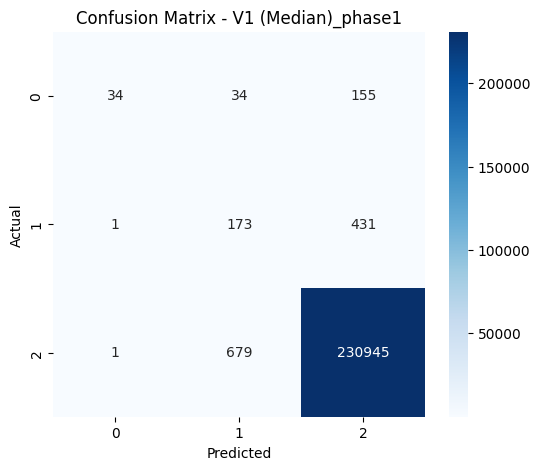

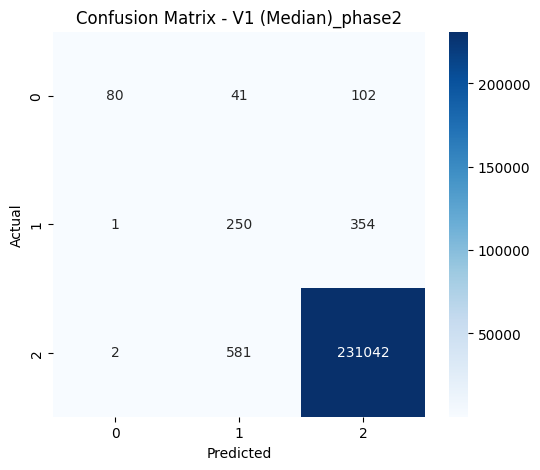

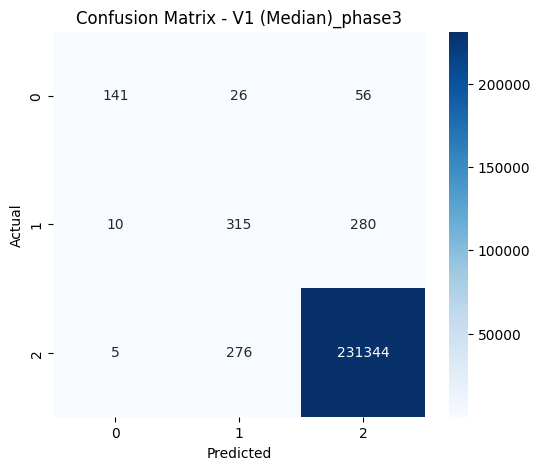

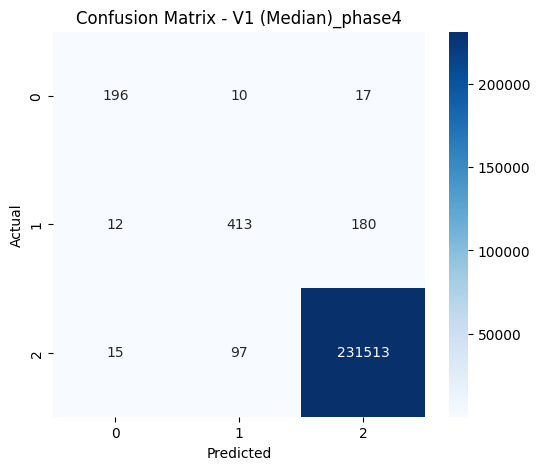

In [13]:
df_v1 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V1 (Median)"
)

df_v1

In [14]:
df_v1.to_csv("results_v1.csv", index=False)

## V2 (Median_CDSMOTE)


#####
Version: V2 (Median CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0520
Epoch 2: loss = 0.0263
Epoch 3: loss = 0.0224
Epoch 4: loss = 0.0204
Epoch 5: loss = 0.0191
Epoch 6: loss = 0.0181
Epoch 7: loss = 0.0173
Epoch 8: loss = 0.0167
Epoch 9: loss = 0.0162
Epoch 10: loss = 0.0158
Epoch 11: loss = 0.0155
Epoch 12: loss = 0.0153
Epoch 13: loss = 0.0149
Epoch 14: loss = 0.0147
Epoch 15: loss = 0.0146
Epoch 16: loss = 0.0144
Epoch 17: loss = 0.0142
Epoch 18: loss = 0.0140
Epoch 19: loss = 0.0139
Epoch 20: loss = 0.0139
Epoch 21: loss = 0.0136
Epoch 22: loss = 0.0135
Epoch 23: loss = 0.0135
Epoch 24: loss = 0.0133
Epoch 25: loss = 0.0133
Epoch 26: loss = 0.0133
Epoch 27: loss = 0.0131
Epoch 28: loss = 0.0130
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V2 (Median CDSMOTE),1,4044.241352,0.054971,0.995612,0.406814,0.703870,0.994701,0.406814,0.995612,0.444531,0.994820,0.338092,0.169887,0.158182,0.923077,0.107623,0.192771,0.328059,0.191667,0.114050,0.143005,0.337500,0.996867,0.998770,0.997818,0.349042
1,V2 (Median CDSMOTE),2,4044.241352,0.055109,0.996137,0.454298,0.714616,0.995049,0.454298,0.996137,0.514568,0.995346,0.415908,0.254206,0.231158,0.866667,0.233184,0.367491,0.482883,0.280142,0.130579,0.178129,0.361198,0.997040,0.999132,0.998085,0.412483
2,V2 (Median CDSMOTE),3,4044.241352,0.055068,0.996442,0.643417,0.660407,0.996159,0.643417,0.996442,0.649137,0.996281,0.670144,0.462272,0.460896,0.528455,0.582960,0.554371,0.763327,0.454741,0.348760,0.394761,0.590237,0.998024,0.998532,0.998278,0.667985
3,V2 (Median CDSMOTE),4,4044.241352,0.054993,0.995423,0.909325,0.611872,0.997568,0.909325,0.995423,0.708376,0.996227,0.934900,0.612434,0.575315,0.415449,0.892377,0.566952,0.944087,0.420530,0.839669,0.560397,0.914950,0.999636,0.995929,0.997779,0.945988


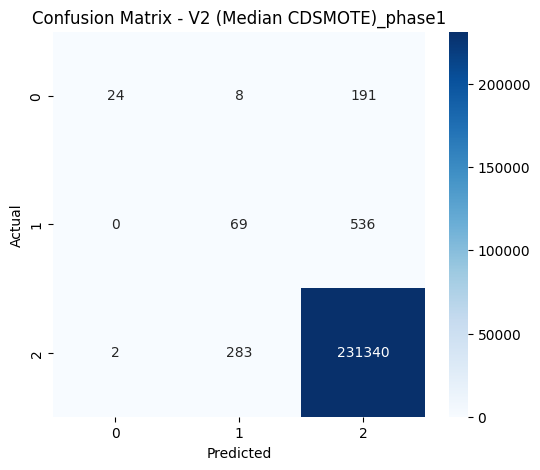

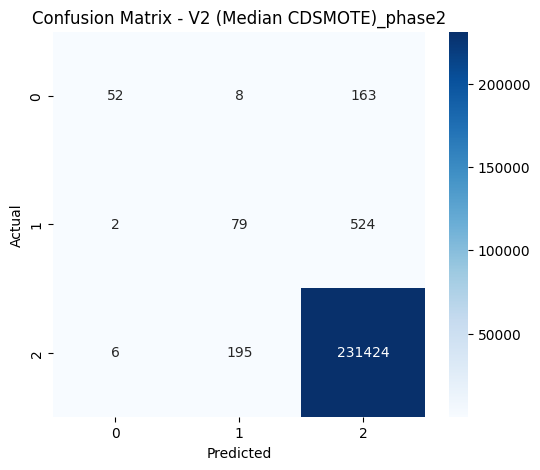

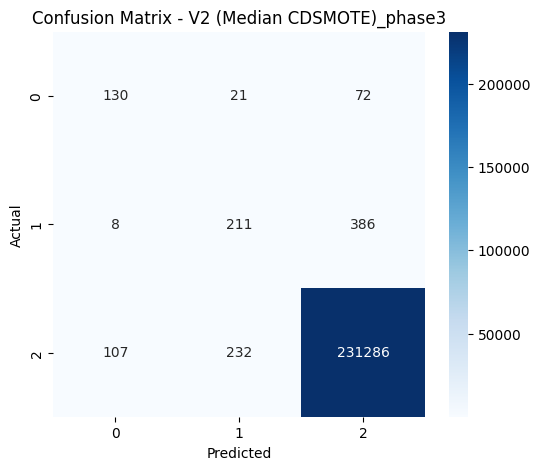

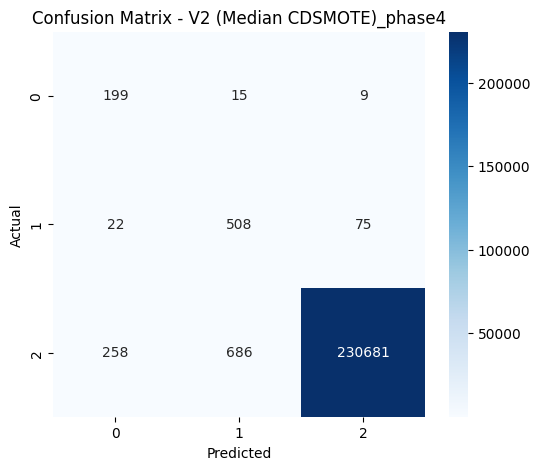

In [15]:
df_v2 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V2 (Median CDSMOTE)"
)

df_v2

In [16]:
df_v2.to_csv("results_v2.csv", index=False)

## V3 (Median SASMOTE)


#####
Version: V3 (Median SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0511
Epoch 2: loss = 0.0260
Epoch 3: loss = 0.0222
Epoch 4: loss = 0.0202
Epoch 5: loss = 0.0189
Epoch 6: loss = 0.0180
Epoch 7: loss = 0.0174
Epoch 8: loss = 0.0167
Epoch 9: loss = 0.0163
Epoch 10: loss = 0.0160
Epoch 11: loss = 0.0156
Epoch 12: loss = 0.0152
Epoch 13: loss = 0.0151
Epoch 14: loss = 0.0148
Epoch 15: loss = 0.0145
Epoch 16: loss = 0.0143
Epoch 17: loss = 0.0142
Epoch 18: loss = 0.0140
Epoch 19: loss = 0.0139
Epoch 20: loss = 0.0138
Epoch 21: loss = 0.0136
Epoch 22: loss = 0.0136
Epoch 23: loss = 0.0135
Epoch 24: loss = 0.0133
Epoch 25: loss = 0.0133
Epoch 26: loss = 0.0131
Epoch 27: loss = 0.0131
Epoch 28: loss = 0.0131
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V3 (Median SASMOTE),1,4123.97676,0.054981,0.996434,0.427614,0.731081,0.995056,0.427614,0.996434,0.485427,0.995330,0.355116,0.240439,0.188754,0.830189,0.197309,0.318841,0.444187,0.366197,0.085950,0.139224,0.293116,0.996857,0.999581,0.998217,0.343959
1,V3 (Median SASMOTE),2,4123.97676,0.054854,0.996984,0.494759,0.895221,0.996459,0.494759,0.996984,0.570215,0.995909,0.434688,0.395137,0.296268,0.896907,0.390135,0.543750,0.624594,0.791667,0.094215,0.168390,0.306934,0.997090,0.999927,0.998506,0.428441
2,V3 (Median SASMOTE),3,4123.97676,0.054779,0.996700,0.711551,0.678499,0.996644,0.711551,0.996700,0.679746,0.996603,0.729427,0.519434,0.519069,0.472934,0.744395,0.578397,0.862439,0.564286,0.391736,0.462439,0.625641,0.998278,0.998523,0.998401,0.719271
3,V3 (Median SASMOTE),4,4123.97676,0.055088,0.996163,0.918998,0.637848,0.997790,0.918998,0.996163,0.732991,0.996760,0.942086,0.651402,0.621281,0.427966,0.905830,0.581295,0.951197,0.485902,0.854545,0.619533,0.923325,0.999675,0.996620,0.998145,0.952022


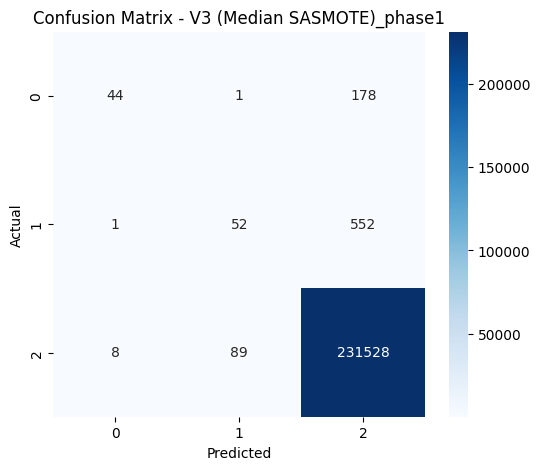

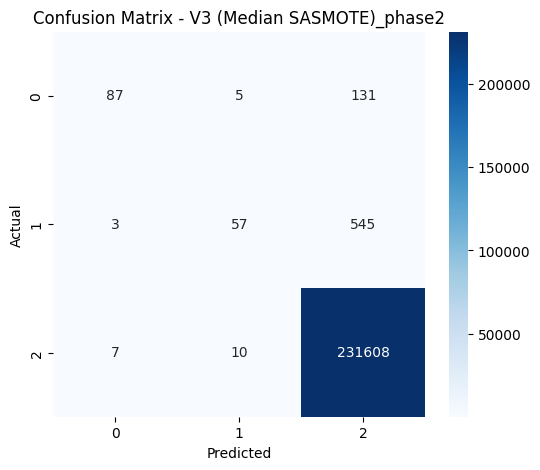

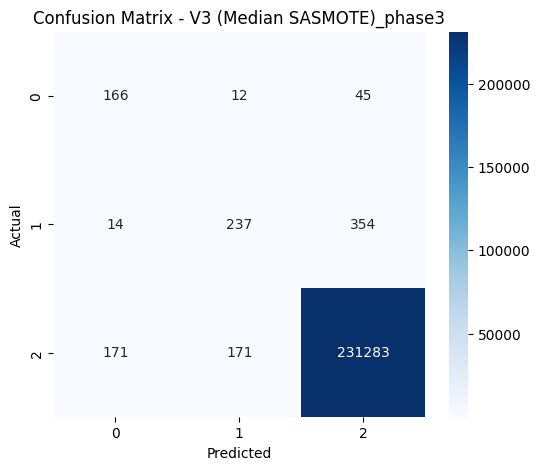

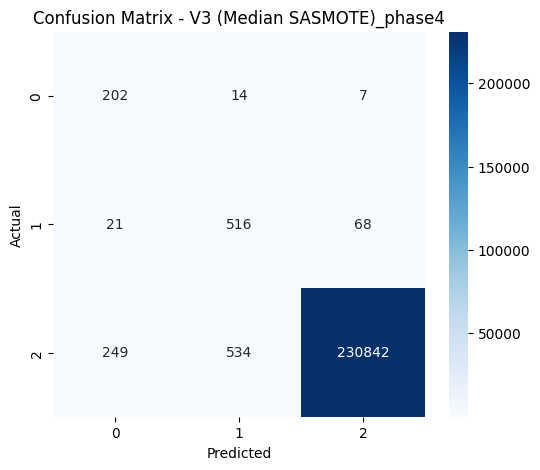

In [17]:
df_v3 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V3 (Median SASMOTE)"
)

df_v3

In [18]:
df_v3.to_csv("results_v3.csv", index=False)

## V4 (Median RadiusSMOTE)


#####
Version: V4 (Median RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0406
Epoch 2: loss = 0.0187
Epoch 3: loss = 0.0157
Epoch 4: loss = 0.0141
Epoch 5: loss = 0.0133
Epoch 6: loss = 0.0126
Epoch 7: loss = 0.0120
Epoch 8: loss = 0.0115
Epoch 9: loss = 0.0112
Epoch 10: loss = 0.0111
Epoch 11: loss = 0.0107
Epoch 12: loss = 0.0105
Epoch 13: loss = 0.0103
Epoch 14: loss = 0.0102
Epoch 15: loss = 0.0101
Epoch 16: loss = 0.0099
Epoch 17: loss = 0.0098
Epoch 18: loss = 0.0098
Epoch 19: loss = 0.0096
Epoch 20: loss = 0.0096
Epoch 21: loss = 0.0095
Epoch 22: loss = 0.0094
Epoch 23: loss = 0.0093
Epoch 24: loss = 0.0093
Epoch 25: loss = 0.0092
Epoch 26: loss = 0.0092
Epoch 27: loss = 0.0091
Epoch 28: loss = 0.00

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V4 (Median RadiusSMOTE),1,3999.322652,0.054801,0.996515,0.477983,0.665612,0.995538,0.477983,0.996515,0.530835,0.995744,0.462445,0.329526,0.296394,0.427481,0.251121,0.316384,0.501039,0.572165,0.183471,0.277847,0.428259,0.997191,0.999357,0.998273,0.460894
1,V4 (Median RadiusSMOTE),2,3999.322652,0.054676,0.997126,0.558778,0.792509,0.996517,0.558778,0.997126,0.635591,0.996617,0.586885,0.487394,0.458087,0.752294,0.367713,0.493976,0.606358,0.627517,0.309091,0.414175,0.555826,0.997716,0.999529,0.998622,0.599778
2,V4 (Median RadiusSMOTE),3,3999.322652,0.054783,0.996782,0.715078,0.678301,0.996828,0.715078,0.996782,0.693191,0.996794,0.756904,0.552474,0.552430,0.508651,0.659193,0.574219,0.811659,0.527728,0.487603,0.506873,0.697888,0.998523,0.998437,0.998480,0.765532
3,V4 (Median RadiusSMOTE),4,3999.322652,0.054808,0.997002,0.832023,0.674496,0.997662,0.832023,0.997002,0.736560,0.997269,0.876680,0.653899,0.645394,0.481283,0.807175,0.603015,0.898054,0.542857,0.690909,0.608000,0.830578,0.999347,0.997984,0.998665,0.903319


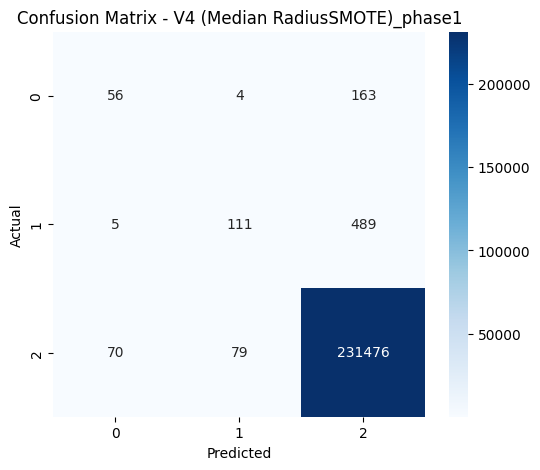

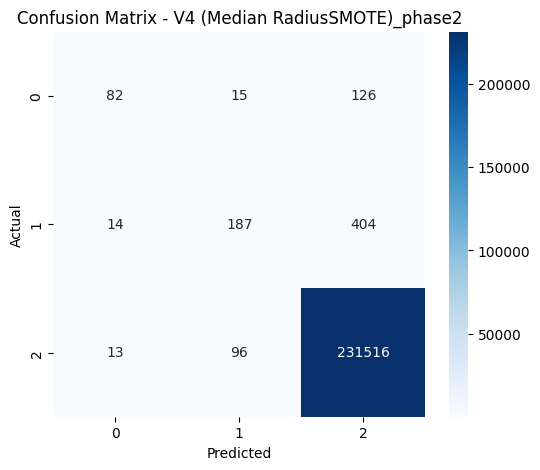

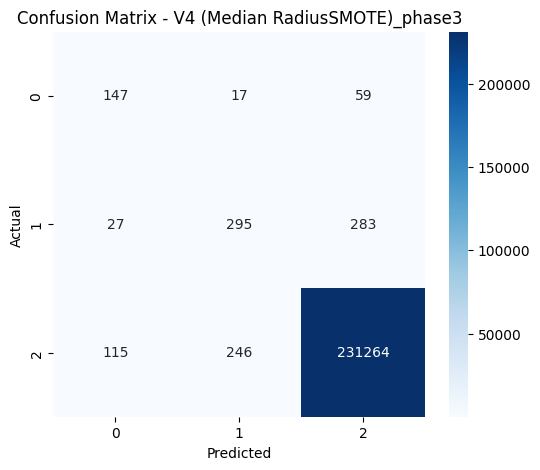

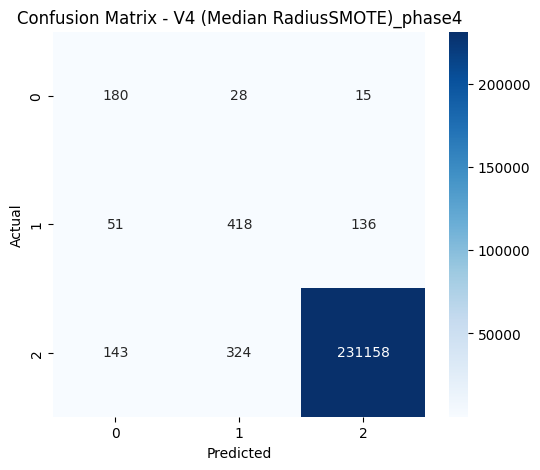

In [19]:
df_v4 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_median_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V4 (Median RadiusSMOTE)"
)

df_v4

In [20]:
df_v4.to_csv("results_v4.csv", index=False)

## V5 (Mean)

In [21]:
base_path = "/kaggle/input/lo-dataset/Mean/Mean"


#####
Version: V5 (Mean)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0084
Epoch 2: loss = 0.0056
Epoch 3: loss = 0.0051
Epoch 4: loss = 0.0048
Epoch 5: loss = 0.0046
Epoch 6: loss = 0.0044
Epoch 7: loss = 0.0042
Epoch 8: loss = 0.0041
Epoch 9: loss = 0.0040
Epoch 10: loss = 0.0038
Epoch 11: loss = 0.0038
Epoch 12: loss = 0.0037
Epoch 13: loss = 0.0036
Epoch 14: loss = 0.0036
Epoch 15: loss = 0.0035
Epoch 16: loss = 0.0034
Epoch 17: loss = 0.0034
Epoch 18: loss = 0.0033
Epoch 19: loss = 0.0032
Epoch 20: loss = 0.0032
Epoch 21: loss = 0.0032
Epoch 22: loss = 0.0032
Epoch 23: loss = 0.0031
Epoch 24: loss = 0.0032
Epoch 25: loss = 0.0031
Epoch 26: loss = 0.0031
Epoch 27: loss = 0.0031
Epoch 28: loss = 0.0031
Epoch 29: loss = 0.0030
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V5 (Mean),1,1446.640832,0.054702,0.992463,0.600394,0.476504,0.995262,0.600394,0.992463,0.488000,0.993707,0.617422,0.269006,0.256459,0.117647,0.565022,0.194745,0.750149,0.313978,0.241322,0.272897,0.490908,0.997887,0.994836,0.996359,0.639146
1,V5 (Mean),2,1446.640832,0.054817,0.995707,0.659598,0.587866,0.995960,0.659598,0.995707,0.609700,0.995789,0.684787,0.424973,0.424465,0.353383,0.632287,0.453376,0.794723,0.412109,0.348760,0.377798,0.590176,0.998104,0.997746,0.997925,0.684652
2,V5 (Mean),3,1446.640832,0.055135,0.994050,0.759979,0.560774,0.996571,0.759979,0.994050,0.599269,0.995132,0.790162,0.437649,0.416697,0.185304,0.780269,0.299484,0.881872,0.498366,0.504132,0.501233,0.709552,0.998653,0.995536,0.997092,0.788422
3,V5 (Mean),4,1446.640832,0.054843,0.998563,0.844169,0.892797,0.998513,0.844169,0.998563,0.867325,0.998533,0.876738,0.790264,0.789622,0.915000,0.820628,0.865248,0.905852,0.764184,0.712397,0.737382,0.843794,0.999206,0.999482,0.999344,0.881689


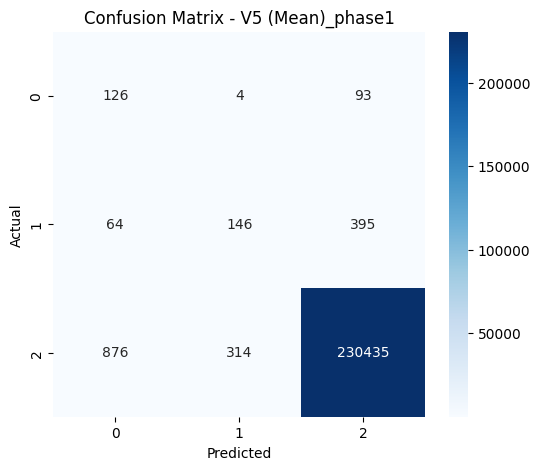

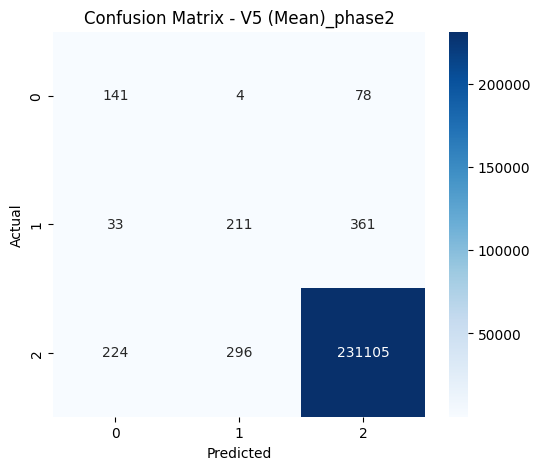

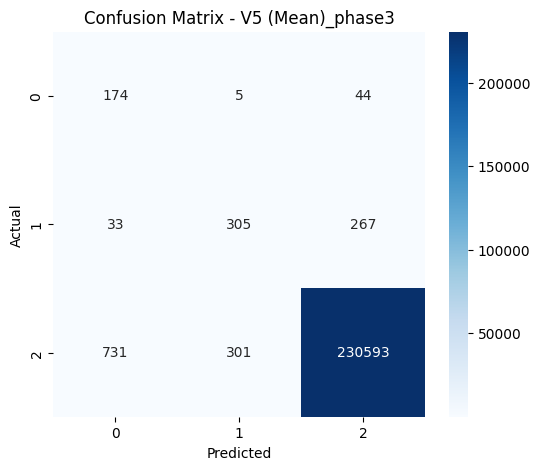

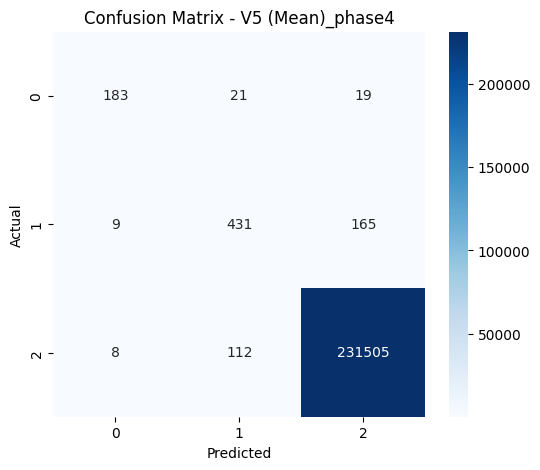

In [22]:
df_v5 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V5 (Mean)"
)

df_v5

In [23]:
df_v5.to_csv("results_v5.csv", index=False)

## V6 (Mean CDSMOTE)


#####
Version: V6 (Mean CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0524
Epoch 2: loss = 0.0280
Epoch 3: loss = 0.0239
Epoch 4: loss = 0.0216
Epoch 5: loss = 0.0203
Epoch 6: loss = 0.0194
Epoch 7: loss = 0.0187
Epoch 8: loss = 0.0181
Epoch 9: loss = 0.0176
Epoch 10: loss = 0.0171
Epoch 11: loss = 0.0167
Epoch 12: loss = 0.0164
Epoch 13: loss = 0.0161
Epoch 14: loss = 0.0160
Epoch 15: loss = 0.0158
Epoch 16: loss = 0.0157
Epoch 17: loss = 0.0155
Epoch 18: loss = 0.0153
Epoch 19: loss = 0.0150
Epoch 20: loss = 0.0151
Epoch 21: loss = 0.0149
Epoch 22: loss = 0.0148
Epoch 23: loss = 0.0147
Epoch 24: loss = 0.0145
Epoch 25: loss = 0.0145
Epoch 26: loss = 0.0145
Epoch 27: loss = 0.0144
Epoch 28: loss = 0.0143
Epoch 29: los

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V6 (Mean CDSMOTE),1,4061.758135,0.055099,0.992515,0.638306,0.468798,0.995210,0.638306,0.992515,0.492002,0.993679,0.631479,0.279965,0.266495,0.149338,0.708520,0.246682,0.840104,0.259109,0.211570,0.232939,0.459604,0.997947,0.994828,0.996385,0.652169
1,V6 (Mean CDSMOTE),2,4061.758135,0.054833,0.995061,0.709522,0.580173,0.996308,0.709522,0.995061,0.594407,0.995520,0.726545,0.423995,0.418169,0.239888,0.771300,0.365957,0.877206,0.502304,0.360331,0.419634,0.599996,0.998327,0.996935,0.997630,0.728681
2,V6 (Mean CDSMOTE),3,4061.758135,0.054797,0.995634,0.809370,0.604605,0.997053,0.809370,0.995634,0.660315,0.996206,0.838752,0.539050,0.524805,0.294479,0.860987,0.438857,0.926974,0.520362,0.570248,0.544164,0.754630,0.998975,0.996874,0.997923,0.843527
3,V6 (Mean CDSMOTE),4,4061.758135,0.054965,0.996120,0.901470,0.635591,0.997698,0.901470,0.996120,0.727131,0.996710,0.929585,0.640153,0.612286,0.436123,0.887892,0.584934,0.941761,0.471035,0.819835,0.598311,0.904359,0.999615,0.996684,0.998147,0.943161


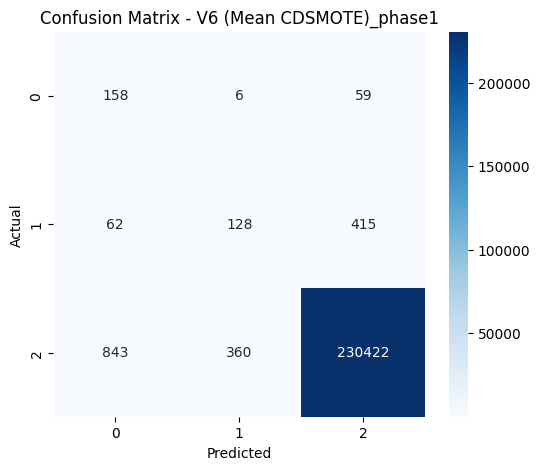

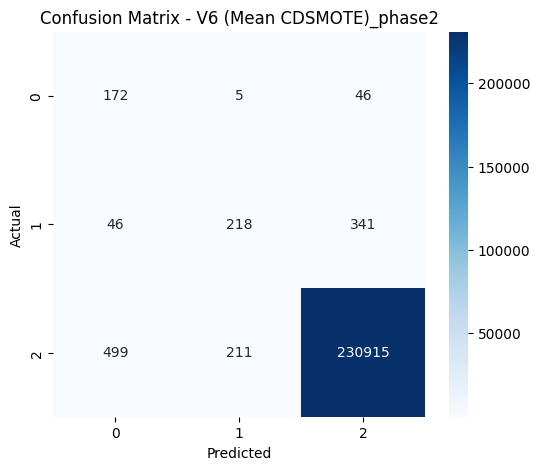

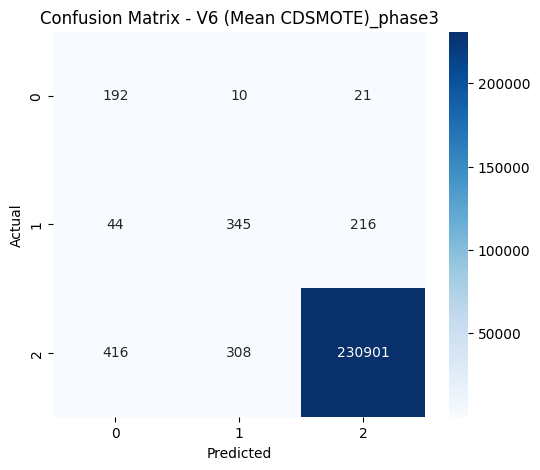

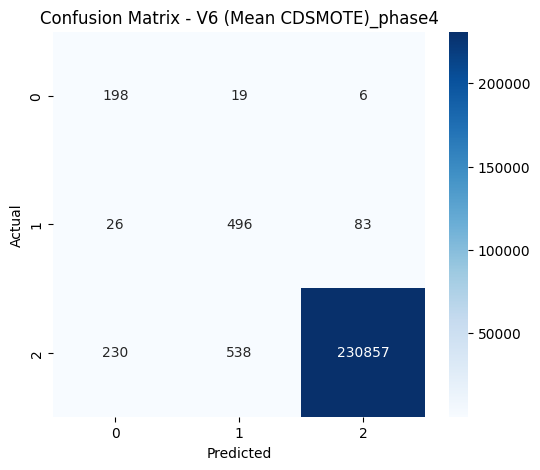

In [24]:
df_v6 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V6 (Mean CDSMOTE)"
)

df_v6

In [25]:
df_v6.to_csv("results_v6.csv", index=False)

## V7 (Mean SASMOTE)


#####
Version: V7 (Mean SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0535
Epoch 2: loss = 0.0286
Epoch 3: loss = 0.0242
Epoch 4: loss = 0.0221
Epoch 5: loss = 0.0207
Epoch 6: loss = 0.0198
Epoch 7: loss = 0.0189
Epoch 8: loss = 0.0184
Epoch 9: loss = 0.0179
Epoch 10: loss = 0.0174
Epoch 11: loss = 0.0171
Epoch 12: loss = 0.0167
Epoch 13: loss = 0.0165
Epoch 14: loss = 0.0163
Epoch 15: loss = 0.0161
Epoch 16: loss = 0.0160
Epoch 17: loss = 0.0157
Epoch 18: loss = 0.0155
Epoch 19: loss = 0.0155
Epoch 20: loss = 0.0152
Epoch 21: loss = 0.0151
Epoch 22: loss = 0.0150
Epoch 23: loss = 0.0149
Epoch 24: loss = 0.0147
Epoch 25: loss = 0.0147
Epoch 26: loss = 0.0146
Epoch 27: loss = 0.0145
Epoch 28: loss = 0.0144
Epoch 29: los

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V7 (Mean SASMOTE),1,4064.099923,0.054962,0.991258,0.650417,0.452001,0.995359,0.650417,0.991258,0.492936,0.993121,0.682486,0.292132,0.266889,0.129003,0.632287,0.214286,0.793533,0.228804,0.325620,0.268759,0.569813,0.998195,0.993343,0.995763,0.703045
1,V7 (Mean SASMOTE),2,4064.099923,0.054789,0.991968,0.698248,0.480368,0.995772,0.698248,0.991968,0.527042,0.993670,0.734342,0.342336,0.314361,0.143527,0.686099,0.237393,0.826681,0.299166,0.414876,0.347645,0.643291,0.998412,0.993770,0.996086,0.744644
2,V7 (Mean SASMOTE),3,4064.099923,0.054835,0.993693,0.773467,0.536037,0.996372,0.773467,0.993693,0.588151,0.994833,0.795395,0.427701,0.403682,0.204104,0.847534,0.328982,0.919154,0.405330,0.477686,0.438543,0.690516,0.998679,0.995182,0.996927,0.792842
3,V7 (Mean SASMOTE),4,4064.099923,0.055112,0.995079,0.914705,0.606908,0.997549,0.914705,0.995079,0.704949,0.996006,0.939909,0.603173,0.560801,0.429806,0.892377,0.580175,0.944120,0.391239,0.856198,0.537066,0.923700,0.999679,0.995540,0.997605,0.952138


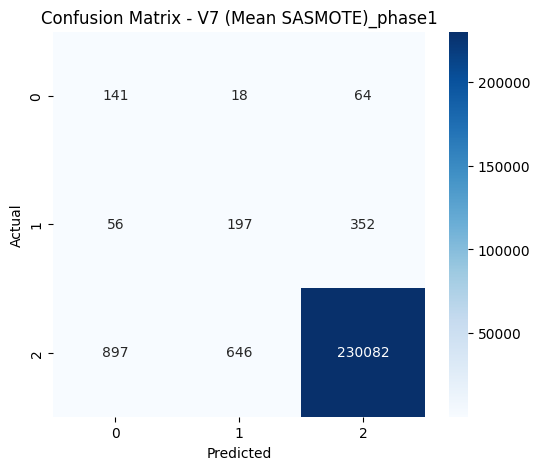

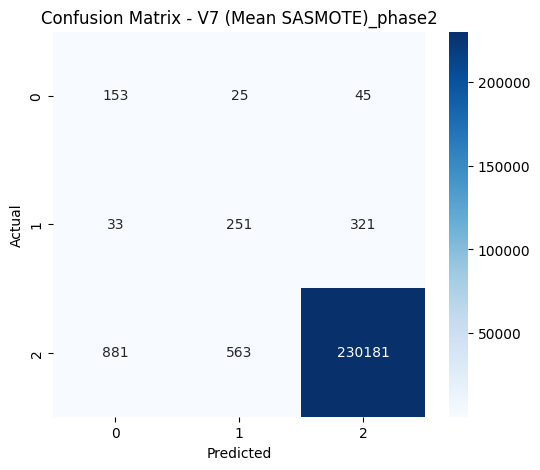

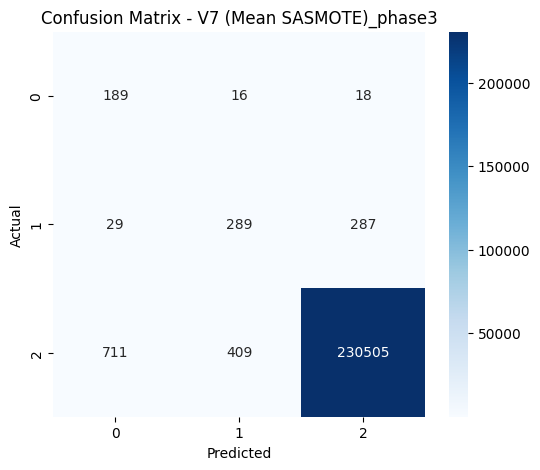

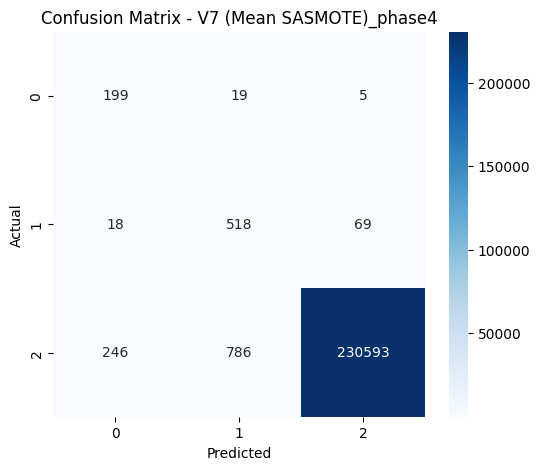

In [26]:
df_v7 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V7 (Mean SASMOTE)"
)

df_v7

In [27]:
df_v7.to_csv("results_v7.csv", index=False)

## V8 (Mean RadiusSMOTE)


#####
Version: V8 (Mean RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0489
Epoch 2: loss = 0.0239
Epoch 3: loss = 0.0193
Epoch 4: loss = 0.0171
Epoch 5: loss = 0.0158
Epoch 6: loss = 0.0148
Epoch 7: loss = 0.0141
Epoch 8: loss = 0.0136
Epoch 9: loss = 0.0132
Epoch 10: loss = 0.0129
Epoch 11: loss = 0.0126
Epoch 12: loss = 0.0124
Epoch 13: loss = 0.0122
Epoch 14: loss = 0.0120
Epoch 15: loss = 0.0118
Epoch 16: loss = 0.0118
Epoch 17: loss = 0.0115
Epoch 18: loss = 0.0115
Epoch 19: loss = 0.0113
Epoch 20: loss = 0.0112
Epoch 21: loss = 0.0111
Epoch 22: loss = 0.0110
Epoch 23: loss = 0.0109
Epoch 24: loss = 0.0109
Epoch 25: loss = 0.0108
Epoch 26: loss = 0.0107
Epoch 27: loss = 0.0108
Epoch 28: loss = 0.0106
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V8 (Mean RadiusSMOTE),1,4268.454389,0.054955,0.990179,0.643079,0.456452,0.995367,0.643079,0.990179,0.479239,0.992561,0.663776,0.261842,0.233950,0.094473,0.659193,0.165261,0.809440,0.276771,0.277686,0.277228,0.526460,0.998111,0.992358,0.995226,0.686302
1,V8 (Mean RadiusSMOTE),2,4268.454389,0.054998,0.991443,0.670895,0.471709,0.995682,0.670895,0.991443,0.509093,0.993371,0.710339,0.316704,0.288579,0.117840,0.645740,0.199308,0.801712,0.298942,0.373554,0.332109,0.610491,0.998347,0.993390,0.995862,0.732316
2,V8 (Mean RadiusSMOTE),3,4268.454389,0.054972,0.996309,0.734870,0.624765,0.996878,0.734870,0.996309,0.662770,0.996544,0.783338,0.541711,0.538291,0.359155,0.686099,0.471495,0.827824,0.516393,0.520661,0.518519,0.721109,0.998747,0.997850,0.998298,0.805209
3,V8 (Mean RadiusSMOTE),4,4268.454389,0.055166,0.996619,0.848858,0.662935,0.997625,0.848858,0.996619,0.735286,0.997018,0.892219,0.641553,0.626368,0.516854,0.825112,0.635579,0.908020,0.472492,0.723967,0.571802,0.849965,0.999459,0.997496,0.998477,0.920276


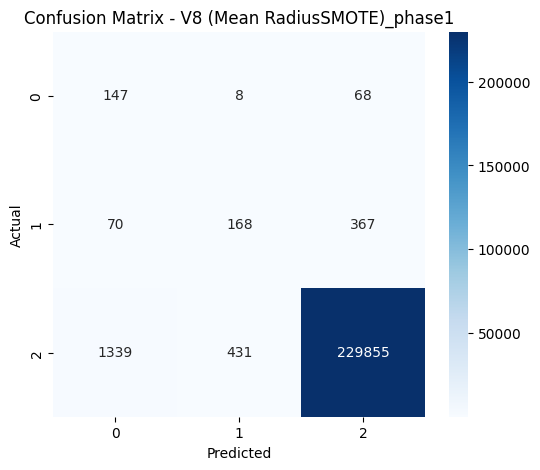

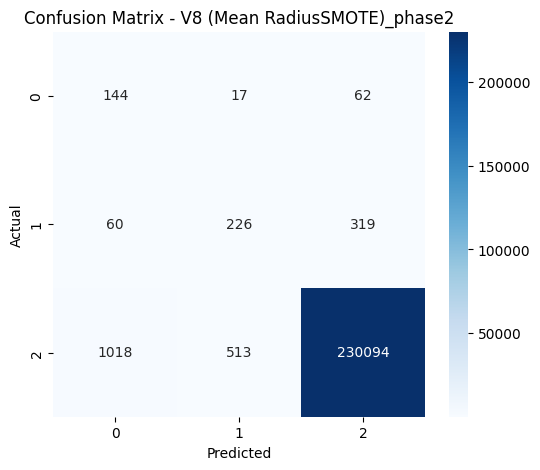

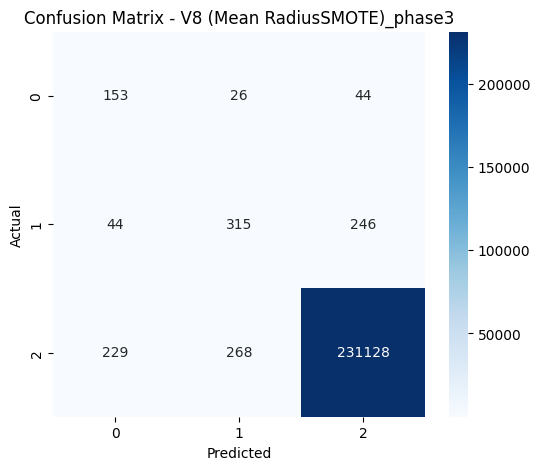

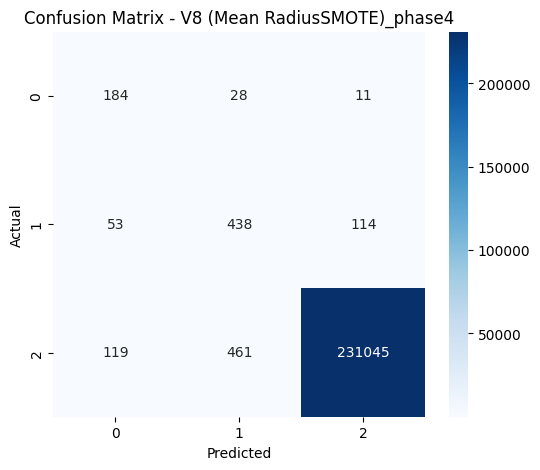

In [28]:
df_v8 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_mean_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V8 (Mean RadiusSMOTE)"
)

df_v8

In [29]:
df_v8.to_csv("results_v8.csv", index=False)

## V9 (MissForest)

In [30]:
base_path = "/kaggle/input/lo-dataset/Extra_trees/Extra_trees"


#####
Version: V9 (MissForest)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0090
Epoch 2: loss = 0.0057
Epoch 3: loss = 0.0050
Epoch 4: loss = 0.0046
Epoch 5: loss = 0.0042
Epoch 6: loss = 0.0040
Epoch 7: loss = 0.0038
Epoch 8: loss = 0.0036
Epoch 9: loss = 0.0034
Epoch 10: loss = 0.0033
Epoch 11: loss = 0.0032
Epoch 12: loss = 0.0032
Epoch 13: loss = 0.0030
Epoch 14: loss = 0.0030
Epoch 15: loss = 0.0029
Epoch 16: loss = 0.0029
Epoch 17: loss = 0.0028
Epoch 18: loss = 0.0028
Epoch 19: loss = 0.0027
Epoch 20: loss = 0.0027
Epoch 21: loss = 0.0026
Epoch 22: loss = 0.0026
Epoch 23: loss = 0.0025
Epoch 24: loss = 0.0025
Epoch 25: loss = 0.0025
Epoch 26: loss = 0.0025
Epoch 27: loss = 0.0025
Epoch 28: loss = 0.0024
Epoch 29

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V9 (MissForest),1,1313.831398,0.055236,0.964660,0.689554,0.376852,0.995369,0.689554,0.964660,0.405497,0.979071,0.754083,0.179328,0.101496,0.088140,0.609865,0.154020,0.778570,0.043689,0.492562,0.080259,0.691884,0.998728,0.966234,0.982213,0.796024
1,V9 (MissForest),2,1313.831398,0.055222,0.982332,0.705370,0.400518,0.995423,0.705370,0.982332,0.444346,0.988314,0.756417,0.249424,0.183905,0.091549,0.641256,0.160224,0.798334,0.111403,0.490909,0.181596,0.697060,0.998602,0.983944,0.991219,0.777730
2,V9 (MissForest),3,1313.831398,0.055354,0.976017,0.767970,0.466730,0.995912,0.767970,0.976017,0.521550,0.985209,0.818412,0.250785,0.163738,0.331933,0.708520,0.452074,0.841160,0.069285,0.618182,0.124604,0.777680,0.998972,0.977209,0.987970,0.837986
3,V9 (MissForest),4,1313.831398,0.054954,0.998666,0.854418,0.889875,0.998611,0.854418,0.998666,0.871384,0.998633,0.884891,0.805095,0.804375,0.870370,0.843049,0.856492,0.918122,0.800000,0.720661,0.758261,0.848718,0.999253,0.999542,0.999398,0.889214


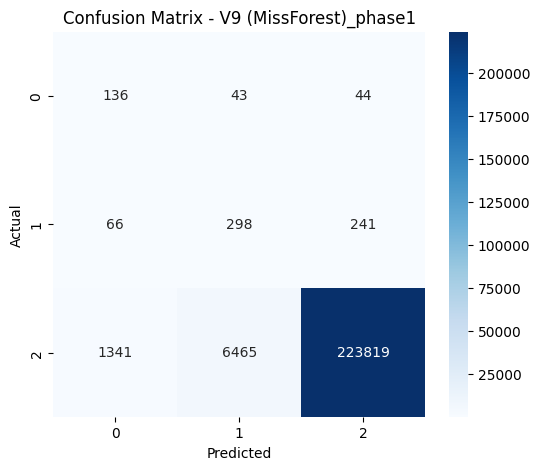

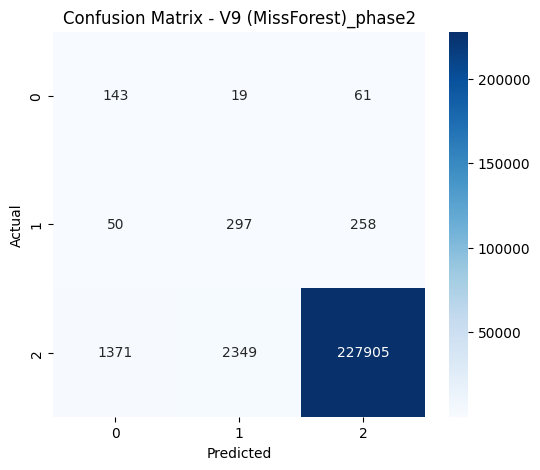

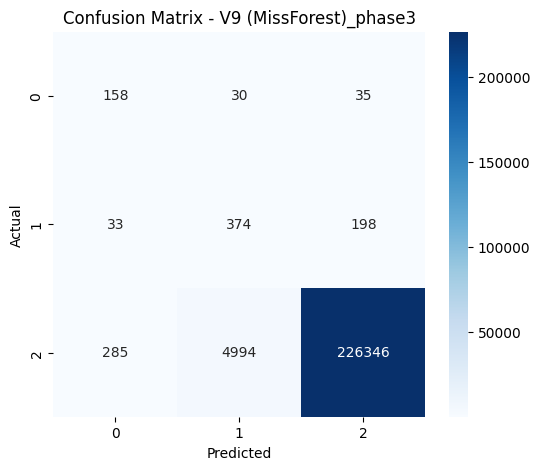

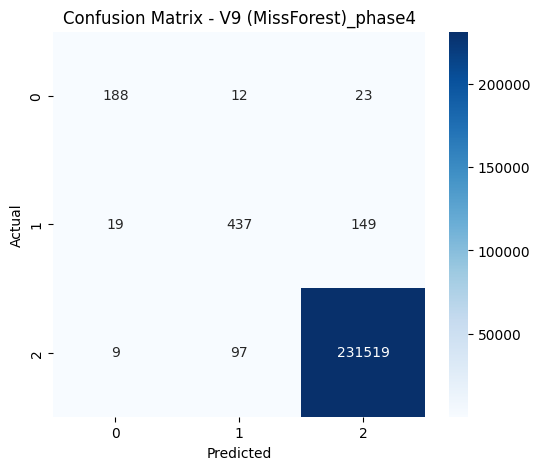

In [31]:
df_v9 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V9 (MissForest)"
)

df_v9

In [32]:
df_v9.to_csv("results_v9.csv", index=False)

## V10 (MissForest CDSMOTE)


#####
Version: V10 (MissForest CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0459
Epoch 2: loss = 0.0201
Epoch 3: loss = 0.0163
Epoch 4: loss = 0.0145
Epoch 5: loss = 0.0133
Epoch 6: loss = 0.0124
Epoch 7: loss = 0.0118
Epoch 8: loss = 0.0114
Epoch 9: loss = 0.0111
Epoch 10: loss = 0.0107
Epoch 11: loss = 0.0105
Epoch 12: loss = 0.0103
Epoch 13: loss = 0.0101
Epoch 14: loss = 0.0099
Epoch 15: loss = 0.0098
Epoch 16: loss = 0.0097
Epoch 17: loss = 0.0095
Epoch 18: loss = 0.0094
Epoch 19: loss = 0.0093
Epoch 20: loss = 0.0092
Epoch 21: loss = 0.0091
Epoch 22: loss = 0.0090
Epoch 23: loss = 0.0090
Epoch 24: loss = 0.0090
Epoch 25: loss = 0.0089
Epoch 26: loss = 0.0088
Epoch 27: loss = 0.0087
Epoch 28: loss 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V10 (MissForest CDSMOTE),1,4336.015591,0.055233,0.993349,0.516349,0.429260,0.994228,0.516349,0.993349,0.431004,0.993632,0.434016,0.177671,0.176283,0.133333,0.493274,0.209924,0.701252,0.157205,0.059504,0.086331,0.243833,0.997243,0.996270,0.996756,0.478135
1,V10 (MissForest CDSMOTE),2,4336.015591,0.055113,0.993280,0.539322,0.488056,0.994440,0.539322,0.993280,0.509957,0.993843,0.512588,0.210073,0.207266,0.366438,0.479821,0.415534,0.692415,0.100350,0.142149,0.117647,0.376399,0.997380,0.995998,0.996688,0.516762
2,V10 (MissForest CDSMOTE),3,4336.015591,0.055185,0.993341,0.692352,0.544983,0.995675,0.692352,0.993341,0.598772,0.994397,0.720470,0.361938,0.344917,0.440341,0.695067,0.539130,0.833353,0.196309,0.386777,0.260434,0.620628,0.998298,0.995212,0.996753,0.723082
3,V10 (MissForest CDSMOTE),4,4336.015591,0.055102,0.996266,0.896251,0.648154,0.997728,0.896251,0.996266,0.736899,0.996812,0.926708,0.647076,0.621060,0.475369,0.865471,0.613672,0.929880,0.469484,0.826446,0.598802,0.907983,0.999610,0.996835,0.998221,0.942594


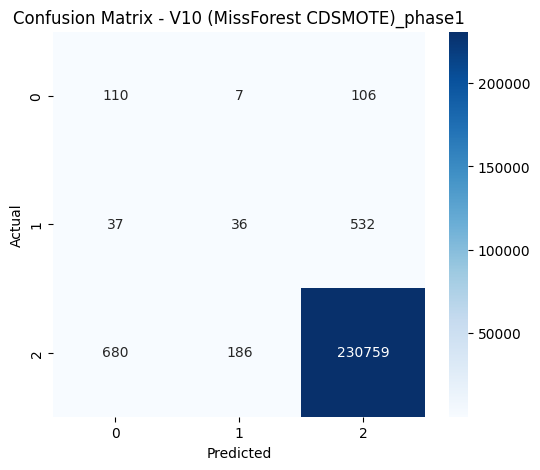

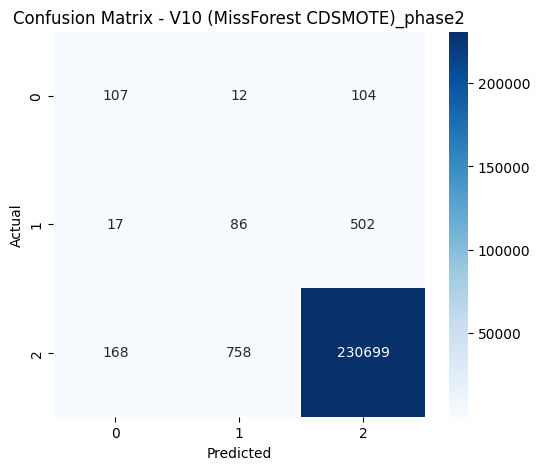

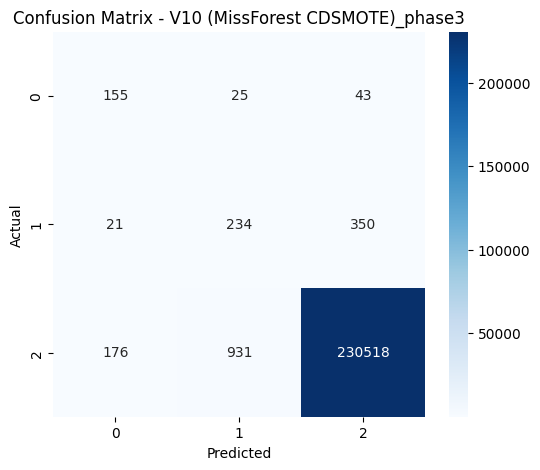

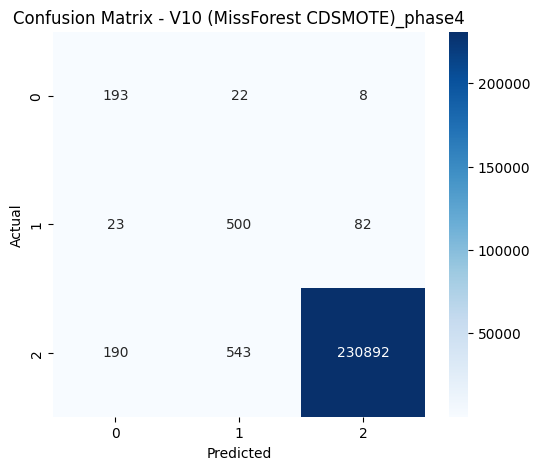

In [33]:
df_v10 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V10 (MissForest CDSMOTE)"
)

df_v10

In [34]:
df_v10.to_csv("results_v10.csv", index=False)

## V11 (MissForest SASMOTE)


#####
Version: V11 (MissForest SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0455
Epoch 2: loss = 0.0202
Epoch 3: loss = 0.0163
Epoch 4: loss = 0.0145
Epoch 5: loss = 0.0133
Epoch 6: loss = 0.0125
Epoch 7: loss = 0.0119
Epoch 8: loss = 0.0113
Epoch 9: loss = 0.0110
Epoch 10: loss = 0.0107
Epoch 11: loss = 0.0104
Epoch 12: loss = 0.0103
Epoch 13: loss = 0.0100
Epoch 14: loss = 0.0099
Epoch 15: loss = 0.0097
Epoch 16: loss = 0.0096
Epoch 17: loss = 0.0094
Epoch 18: loss = 0.0093
Epoch 19: loss = 0.0092
Epoch 20: loss = 0.0092
Epoch 21: loss = 0.0092
Epoch 22: loss = 0.0090
Epoch 23: loss = 0.0090
Epoch 24: loss = 0.0089
Epoch 25: loss = 0.0089
Epoch 26: loss = 0.0089
Epoch 27: loss = 0.0088
Epoch 28: loss 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V11 (MissForest SASMOTE),1,4414.188851,0.055180,0.996361,0.439800,0.733066,0.995783,0.439800,0.996361,0.455811,0.995057,0.282570,0.214728,0.166611,0.384181,0.304933,0.340000,0.552078,0.818182,0.014876,0.029221,0.121967,0.996836,0.999590,0.998211,0.335071
1,V11 (MissForest SASMOTE),2,4414.188851,0.055124,0.996657,0.536152,0.704497,0.995718,0.536152,0.996657,0.558723,0.995706,0.464809,0.353793,0.313890,0.536697,0.524664,0.530612,0.724179,0.579545,0.084298,0.147186,0.290317,0.997247,0.999495,0.998370,0.477646
2,V11 (MissForest SASMOTE),3,4414.188851,0.055073,0.995982,0.699616,0.616002,0.996375,0.699616,0.995982,0.626172,0.996062,0.716562,0.462661,0.462041,0.334000,0.748879,0.461964,0.864757,0.515738,0.352066,0.418468,0.593096,0.998268,0.997902,0.998085,0.717369
3,V11 (MissForest SASMOTE),4,4414.188851,0.054986,0.996976,0.891853,0.672927,0.997962,0.891853,0.996976,0.754241,0.997345,0.925227,0.686788,0.669275,0.461353,0.856502,0.599686,0.925030,0.557800,0.821488,0.664439,0.905589,0.999628,0.997569,0.998598,0.945493


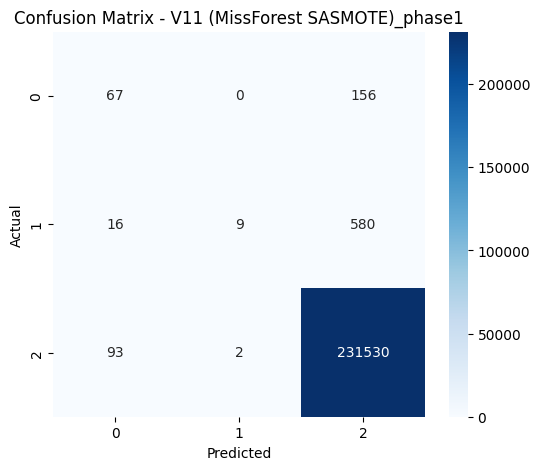

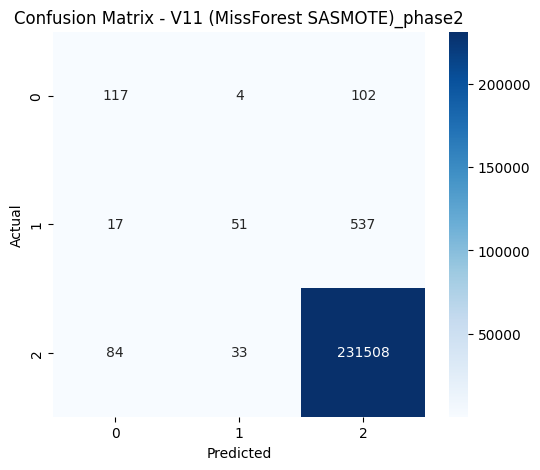

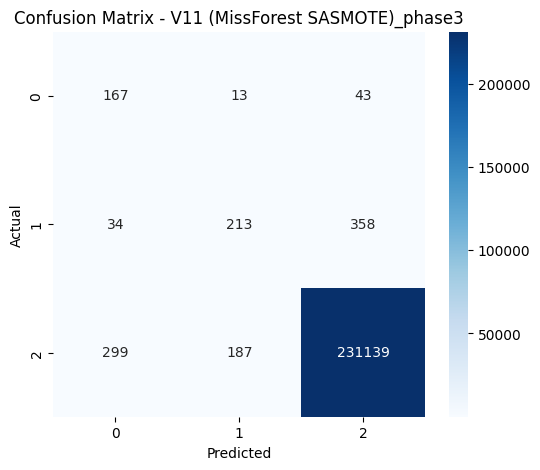

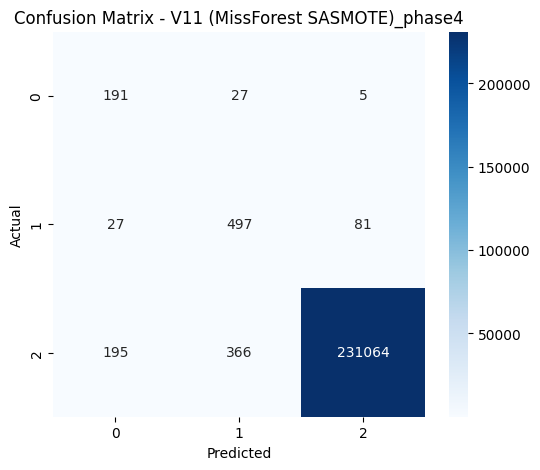

In [35]:
df_v11 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V11 (MissForest SASMOTE)"
)

df_v11

In [36]:
df_v11.to_csv("results_v11.csv", index=False)

## V12 (MissForest RadiusSMOTE)


#####
Version: V12 (MissForest RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0375
Epoch 2: loss = 0.0148
Epoch 3: loss = 0.0120
Epoch 4: loss = 0.0108
Epoch 5: loss = 0.0100
Epoch 6: loss = 0.0095
Epoch 7: loss = 0.0091
Epoch 8: loss = 0.0088
Epoch 9: loss = 0.0086
Epoch 10: loss = 0.0084
Epoch 11: loss = 0.0083
Epoch 12: loss = 0.0082
Epoch 13: loss = 0.0080
Epoch 14: loss = 0.0079
Epoch 15: loss = 0.0079
Epoch 16: loss = 0.0078
Epoch 17: loss = 0.0077
Epoch 18: loss = 0.0077
Epoch 19: loss = 0.0076
Epoch 20: loss = 0.0075
Epoch 21: loss = 0.0075
Epoch 22: loss = 0.0075
Epoch 23: loss = 0.0074
Epoch 24: loss = 0.0073
Epoch 25: loss = 0.0073
Epoch 26: loss = 0.0073
Epoch 27: loss = 0.0073
Epoch 2

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V12 (MissForest RadiusSMOTE),1,4379.020769,0.055295,0.991061,0.537419,0.426852,0.994788,0.537419,0.991061,0.454212,0.992826,0.571184,0.224390,0.208202,0.076841,0.322870,0.124138,0.567157,0.205984,0.295868,0.242877,0.543127,0.997732,0.993520,0.995622,0.604955
1,V12 (MissForest RadiusSMOTE),2,4379.020769,0.055313,0.992708,0.586676,0.466702,0.995305,0.586676,0.992708,0.498181,0.993916,0.632303,0.295868,0.282021,0.115629,0.408072,0.180198,0.637847,0.286472,0.357025,0.317881,0.596822,0.998004,0.994931,0.996465,0.664071
2,V12 (MissForest RadiusSMOTE),3,4379.020769,0.055159,0.991564,0.731681,0.482353,0.996274,0.731681,0.991564,0.540801,0.993653,0.790631,0.392029,0.349204,0.125000,0.605381,0.207214,0.776478,0.323187,0.596694,0.419280,0.771199,0.998871,0.992967,0.995910,0.825328
3,V12 (MissForest RadiusSMOTE),4,4379.020769,0.055314,0.997096,0.827730,0.677946,0.997718,0.827730,0.997096,0.737855,0.997349,0.876182,0.661886,0.653959,0.484848,0.789238,0.600683,0.888033,0.549608,0.695868,0.614150,0.833566,0.999382,0.998083,0.998732,0.908685


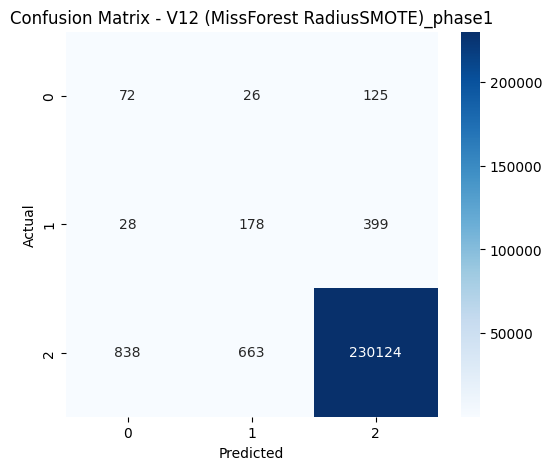

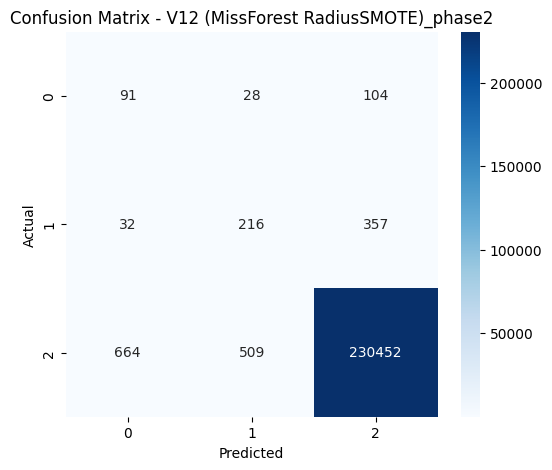

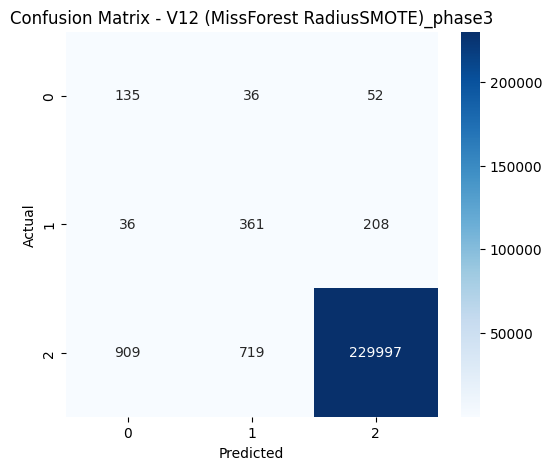

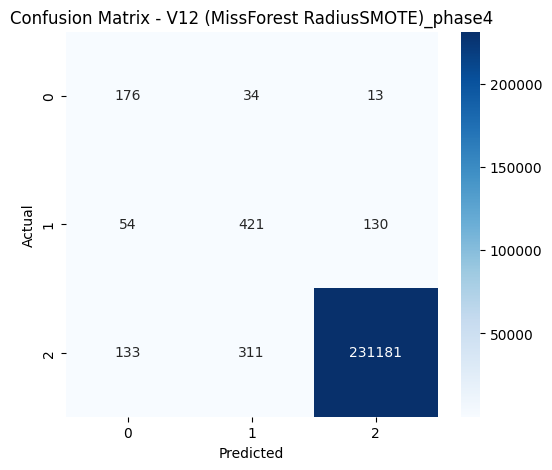

In [37]:
df_v12 = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_extra_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V12 (MissForest RadiusSMOTE)"
)

df_v12

In [38]:
df_v12.to_csv("results_v12.csv", index=False)